# ViT baseline (classical) — NIH Chest X-ray **multi-label** classifier (FULL dataset)

A purely **classical** Vision-Transformer image classifier trained on the **full NIH
ChestX-ray14 dataset** (**112,120 images / 30,805 patients**), built for a **Kaggle**
GPU notebook. This is the **classical control** for the hybrid quantum–classical
`hqnn-nih-chestxray-multilabel-full.ipynb`: identical data, split, backbone, head
dimensions, loss, metrics and training loop — the **only** difference is that the
20-dim bottleneck is passed through a classical **`Linear(20→20) + Tanh`** instead of
the 4 parallel quantum circuits.

The backbone follows the same design as the **HQNN-Parallel** model of Senokosov et
al. 2024 (*"Quantum machine learning for image classification"*, Mach. Learn.: Sci.
Technol. **5** 015040, **section 2.2**) with a small **Vision Transformer (ViT)**
feature extractor; here the parallel-PQC head is swapped for its classical analogue.

## Controlled comparison (same data & split)
This baseline and the HQNN-Parallel notebook both train on the **full 112,120-image
dataset** using NIH's **official split** (`test_list.txt` as the test set; a
patient-disjoint **~85/15** carve of `train_val_list.txt` for train/val), the same
`SEED`, the same epochs/batch size, and the same `BCEWithLogitsLoss(pos_weight)`.
Because everything **except the head** is held fixed, the **delta** between the two
test scores isolates the effect of the quantum layer.

## The task — multi-label, not multi-class
Each X-ray can carry **several findings at once**. We predict **15 classes**
(the 14 pathologies **+ "No Finding"**) as independent probabilities:
- output layer = **15 logits with a sigmoid** (never softmax),
- loss = **`BCEWithLogitsLoss` with `pos_weight`** to fight the heavy class
  imbalance ("No Finding" dominates; some pathologies are rare),
- metrics = **macro / per-class AUROC** and **macro F1@0.5** (plain accuracy is
  meaningless for multi-label).

## Architecture
- **Classical backbone — ViT (no convolutions):** resize to **224×224 grayscale**
  → 16×16 patches (196 patches) → linear patch embedding (dim 128) → prepend CLS
  token + positional embeddings → **4** Transformer encoder layers, **8** heads →
  CLS representation (128-dim).
- **Classical head:** `Linear(128→64)` → GELU → `Linear(64→20)` → BatchNorm → ReLU →
  **`Linear(20→20)` + `Tanh`** → `Linear(20→15)` → BatchNorm → (sigmoid applied
  inside the loss / at evaluation).

## The head this notebook uses (vs. the quantum layer)
Where the HQNN model feeds the 20-dim bottleneck through **4 parallel PQCs** (5
qubits each), this control uses a single **`Linear(20→20)` + `Tanh`**. Same input/
output shape, same position in the head, fully on the **GPU** — there is no CPU
circuit simulation, so training is far faster than the hybrid run.

## Hybrid → all-GPU
Because there is no quantum circuit to simulate on the CPU, the whole forward pass
runs on the GPU under **mixed precision**. The disk-backed **memmap** cache,
**per-epoch checkpoint + resume**, and `num_workers=0` are all kept **identical to
the HQNN run** for parity (this baseline could safely raise `num_workers`, but we
hold every knob fixed except the head).

> **Kaggle tips:** enable the GPU (Settings → Accelerator → GPU), add the
> **`nih-chest-xrays/data`** dataset (all 12 image archives plus `test_list.txt` /
> `train_val_list.txt`), keep `SMOKE_TEST = True` for the first run, then set it to
> `False` and **Save Version → Save & Run All (Commit)** for the full run. This
> GPU-bound baseline usually finishes the full schedule in a single session;
> per-epoch checkpoint + resume are kept regardless.

In [1]:
# 1. Dependencies. torch / torchvision / sklearn ship with Kaggle images.
#    iterative-stratification -> multi-label aware train/val/test split (optional)
#    (No pennylane: this classical baseline has no quantum layer.)
!pip install -q iterative-stratification

In [2]:
# 2. Imports, reproducibility, device.
import os, time, glob, zipfile, random
from collections import defaultdict
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, f1_score, roc_curve

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Wall-clock start of the session; the training loop uses it for the
# MAX_TRAIN_MINUTES soft budget so a commit stops gracefully before Kaggle's wall.
NB_START = time.time()

print("Torch", torch.__version__)
print("Compute device:", device, "(all-GPU: no quantum circuit to simulate)")

Torch 2.10.0+cu128
Compute device: cuda (all-GPU: no quantum circuit to simulate)


## Configuration

Everything you might tune lives here. **`SMOKE_TEST = True`** runs the whole pipeline
on ~500 images for 2 epochs to prove it works end-to-end (build the memmap cache,
split, train, evaluate). Set it to `False` for the real run on the **full dataset**
(`SUBSET_SIZE = None` → all **112,120** images). Every knob — `SEED`, `SUBSET_SIZE`,
the split logic, epochs, batch size — is held **identical to the HQNN-Parallel
notebook** so the two models see the same images and the same split; the only
difference is the classical vs. quantum head. `MAX_TRAIN_MINUTES` still bounds
per-session training time, though this GPU-bound baseline is fast enough to usually
finish in one session.

In [3]:
# 3. Config — full NIH ChestX-ray14 (all 112,120 images; classical ViT control for the HQNN run).
SMOKE_TEST  = False        # True -> ~500 imgs, 2 epochs; False -> full dataset (SUBSET_SIZE images)
SUBSET_SIZE = None         # None -> use ALL 112,120 images; set an int only to cap the run

IMG_SIZE   = 224           # X-rays resized to 224x224 grayscale (1 channel)
PATCH_SIZE = 16            # 224/16 = 14 -> 196 patches
VIT_DIM    = 128
VIT_DEPTH  = 4
VIT_HEADS  = 8
VIT_MLP    = 256

N_QUBITS, N_LAYERS, N_CIRCUITS = 5, 4, 4     # bottleneck dims kept from the quantum run: 4x5 = 20-dim head
NUM_CLASSES = 15                              # 14 pathologies + "No Finding"

LR            = 5e-4
WEIGHT_DECAY  = 1e-4
WARMUP_EPOCHS = 2
POS_WEIGHT_CAP = 25.0      # cap pos_weight so ultra-rare classes don't destabilise loss
USE_AMP = True             # mixed precision on the GPU

NORM_SAMPLE = 3000         # #train images sampled to estimate grayscale mean/std

# Soft wall-clock budget for TRAINING (minutes). Kept for parity with the HQNN run;
# this classical baseline is GPU-bound and usually finishes well inside one session,
# but the loop still checkpoints every epoch and stops before this many minutes.
MAX_TRAIN_MINUTES = 600

# Held identical to the HQNN run for a like-for-like comparison, incl. num_workers=0.
# (This classical baseline is GPU-bound and could use more workers, but we hold every
# knob fixed except the head.)
if SMOKE_TEST:
    EPOCHS, BATCH_SIZE, SUBSET, NUM_WORKERS = 2, 16, 500, 0
else:
    EPOCHS, BATCH_SIZE, SUBSET, NUM_WORKERS = 12, 32, SUBSET_SIZE, 0

# Kaggle paths. The image cache is a disk-backed uint8 memmap on /kaggle/working.
# SPLIT_TAG encodes the subset size so smoke / full / other-size caches never
# collide. SUBSET is None on the full run -> tag "full" (guarded so the modulo on
# None never runs). The image cache tag matches the HQNN run (same images/split);
# checkpoint/best files use a distinct vit_ prefix so artifacts never clash.
WORK_DIR   = "/kaggle/working"
if SMOKE_TEST:
    SPLIT_TAG = "smoke"
elif SUBSET is None:
    SPLIT_TAG = "full"
elif SUBSET % 1000 == 0:
    SPLIT_TAG = f"{SUBSET // 1000}k"
else:
    SPLIT_TAG = str(SUBSET)

CACHE_TAG  = f"nih14_{IMG_SIZE}_{SPLIT_TAG}"
CACHE_IMG  = os.path.join(WORK_DIR, f"{CACHE_TAG}_images.npy")   # memmap uint8 cache
CACHE_LBL  = os.path.join(WORK_DIR, f"{CACHE_TAG}_labels.npy")
CACHE_META = os.path.join(WORK_DIR, f"{CACHE_TAG}_meta.npz")     # names + patient ids
CKPT_PATH  = os.path.join(WORK_DIR, f"vit_nih14_{SPLIT_TAG}_ckpt.pt")
BEST_PATH  = os.path.join(WORK_DIR, f"vit_nih14_{SPLIT_TAG}_best.pt")
RESUME     = True          # resume from CKPT_PATH if it exists

print(f"SMOKE_TEST={SMOKE_TEST} | epochs={EPOCHS} batch={BATCH_SIZE} "
      f"subset={SUBSET} (tag={SPLIT_TAG}) workers={NUM_WORKERS} | max_train_min={MAX_TRAIN_MINUTES}")
print(f"img={IMG_SIZE} patch={PATCH_SIZE} | head: classical Linear("
      f"{N_QUBITS*N_CIRCUITS}->{N_QUBITS*N_CIRCUITS})+Tanh (bottleneck {N_QUBITS*N_CIRCUITS})")

SMOKE_TEST=False | epochs=12 batch=32 subset=None (tag=full) workers=0 | max_train_min=600
img=224 patch=16 | head: classical Linear(20->20)+Tanh (bottleneck 20)


## Data discovery & label parsing

We auto-locate `Data_Entry_2017.csv` and index every PNG under `/kaggle/input` by
filename (the images live in `images_001/images/ … images_012/images/`). Then we
parse the pipe-separated `Finding Labels` into **15-dim multi-hot vectors** and keep
each row's **Patient ID** for the leakage-free, patient-disjoint split.

In [4]:
# 4a. Locate Data_Entry_2017.csv and build a filename -> path map for the FULL set.
def _find(pattern):
    """Recursively find files matching `pattern` anywhere under /kaggle/input."""
    return sorted(glob.glob(f"/kaggle/input/**/{pattern}", recursive=True))

csv_hits = _find("Data_Entry_2017.csv") or _find("Data_Entry_2017_v2020.csv")
assert csv_hits, ("Data_Entry_2017.csv not found under /kaggle/input. "
                  "Add the 'nih-chest-xrays/data' dataset to the notebook.")
CSV_PATH = csv_hits[0]
labels_df = pd.read_csv(CSV_PATH)
print("Labels CSV:", CSV_PATH, "| rows:", len(labels_df))

# Index every PNG by basename (images_001/images/xxx.png ... images_012/images/...).
print("Indexing image files on disk (walks images_001 ... images_012) ...")
png_paths = glob.glob("/kaggle/input/**/images*/**/*.png", recursive=True)
if not png_paths:                                   # fallback: any png under input
    png_paths = glob.glob("/kaggle/input/**/*.png", recursive=True)
img_index = {}
for p in png_paths:
    fn = os.path.basename(p)
    if fn not in img_index:
        img_index[fn] = p
print(f"PNG files indexed: {len(img_index)}")
assert len(img_index) > 0, "No PNGs found; check the dataset attachment."

Labels CSV: /kaggle/input/datasets/nih-chest-xrays/data/Data_Entry_2017.csv | rows: 112120
Indexing image files on disk (walks images_001 ... images_012) ...
PNG files indexed: 112120


In [5]:
# 4b. Parse "Finding Labels" -> 15-dim multi-hot; keep Patient ID for the split.
PATHOLOGIES = [
    "Atelectasis", "Cardiomegaly", "Effusion", "Infiltration", "Mass",
    "Nodule", "Pneumonia", "Pneumothorax", "Consolidation", "Edema",
    "Emphysema", "Fibrosis", "Pleural_Thickening", "Hernia",
]
CLASS_NAMES = PATHOLOGIES + ["No Finding"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
assert len(CLASS_NAMES) == NUM_CLASSES

# Keep only rows whose image we actually found, in a stable order.
labels_df = labels_df[labels_df["Image Index"].isin(img_index)].reset_index(drop=True)
print("Rows with an image on disk:", len(labels_df))

def to_multihot(finding_str):
    vec = np.zeros(NUM_CLASSES, dtype=np.float32)
    for tag in str(finding_str).split("|"):
        tag = tag.strip()
        if tag in CLASS_TO_IDX:
            vec[CLASS_TO_IDX[tag]] = 1.0
    return vec

all_names    = labels_df["Image Index"].tolist()
all_patients = labels_df["Patient ID"].to_numpy()
all_labels   = np.stack([to_multihot(s) for s in labels_df["Finding Labels"]])
print("Multi-hot label matrix:", all_labels.shape,
      "| unique patients:", len(np.unique(all_patients)))

# Class frequencies (a quick sanity check of the imbalance).
freq = all_labels.sum(0).astype(int)
for c, n in sorted(zip(CLASS_NAMES, freq), key=lambda kv: -kv[1]):
    print(f"  {c:20s} {n:6d}  ({100*n/len(all_labels):5.2f}%)")

Rows with an image on disk: 112120
Multi-hot label matrix: (112120, 15) | unique patients: 30805
  No Finding            60361  (53.84%)
  Infiltration          19894  (17.74%)
  Effusion              13317  (11.88%)
  Atelectasis           11559  (10.31%)
  Nodule                 6331  ( 5.65%)
  Mass                   5782  ( 5.16%)
  Pneumothorax           5302  ( 4.73%)
  Consolidation          4667  ( 4.16%)
  Pleural_Thickening     3385  ( 3.02%)
  Cardiomegaly           2776  ( 2.48%)
  Emphysema              2516  ( 2.24%)
  Edema                  2303  ( 2.05%)
  Fibrosis               1686  ( 1.50%)
  Pneumonia              1431  ( 1.28%)
  Hernia                  227  ( 0.20%)


## Preprocess once → disk-backed memmap

Decoding the PNGs every epoch would waste GPU time, so we decode + resize **once**
into a `uint8` **memmap** on `/kaggle/working`; the `Dataset` then pages individual
rows in on access. For the **full 112,120 images** at 224×224 the cache is
**~5.3 GB** of uint8 on disk and builds in roughly **40–55 minutes** the first time
(it decodes every PNG once). After that a **valid cache is reused instantly** on any
re-run/commit — cache validation checks the shape and skips the rebuild — until the
working dir resets.

In [6]:
# 5. Decode + resize once into a uint8 memmap; train from it.
from numpy.lib.format import open_memmap

# Subset (shuffled for class diversity) applied BEFORE caching. On the full run
# SUBSET is None, so every image is kept. Same SEED as the ViT baseline.
sel = np.arange(len(all_names))
if SUBSET is not None and SUBSET < len(sel):
    rng = np.random.default_rng(SEED)
    sel = rng.permutation(sel)[:SUBSET]
    sel.sort()

names_sel    = [all_names[i] for i in sel]
patients_sel = all_patients[sel]
labels_sel   = all_labels[sel]
n_sel = len(names_sel)

# Expected cache footprint + one-time build estimate (printed before build/reuse).
_cache_gb = n_sel * IMG_SIZE * IMG_SIZE / 1e9
_est_lo, _est_hi = n_sel / 50 / 60, n_sel / 40 / 60      # ~40-50 imgs/s decode+resize
print(f"Memmap cache: {n_sel} imgs x {IMG_SIZE}x{IMG_SIZE} uint8 = {_cache_gb:.2f} GB on {WORK_DIR}")
print(f"First build decodes {n_sel} PNGs once (~{_est_lo:.0f}-{_est_hi:.0f} min); "
      f"a valid cache is then reused instantly (no rebuild).")

def cache_is_valid():
    """A cache is reusable iff all three files exist and the image memmap has the
    exact expected shape (n_sel, IMG_SIZE, IMG_SIZE) — so a re-run/commit reuses it
    instead of decoding ~112k PNGs again."""
    if not (os.path.exists(CACHE_IMG) and os.path.exists(CACHE_LBL)
            and os.path.exists(CACHE_META)):
        return False
    try:
        mm = np.load(CACHE_IMG, mmap_mode="r")
        return tuple(mm.shape) == (n_sel, IMG_SIZE, IMG_SIZE)
    except Exception:
        return False

if cache_is_valid():
    images   = np.load(CACHE_IMG, mmap_mode="r")
    labels   = np.load(CACHE_LBL)
    meta     = np.load(CACHE_META, allow_pickle=True)
    patients = meta["patients"]
    names    = list(meta["names"])
    print("Loaded existing cache (memmap):", images.shape, "-> reused, no rebuild")
else:
    print(f"Building memmap cache for {n_sel} images -> {CACHE_IMG}")
    images = open_memmap(CACHE_IMG, mode="w+", dtype=np.uint8,
                         shape=(n_sel, IMG_SIZE, IMG_SIZE))
    t0 = time.time()
    for i, fn in enumerate(names_sel):
        img = Image.open(img_index[fn]).convert("L").resize(
            (IMG_SIZE, IMG_SIZE), Image.BILINEAR)
        images[i] = np.asarray(img, dtype=np.uint8)
        if (i + 1) % 2000 == 0:
            print(f"  {i+1}/{n_sel}  ({time.time()-t0:.0f}s)")
    images.flush()
    labels, patients, names = labels_sel, patients_sel, names_sel
    np.save(CACHE_LBL, labels)
    np.savez(CACHE_META, names=np.array(names, dtype=object), patients=patients)
    images = np.load(CACHE_IMG, mmap_mode="r")      # reopen read-only
    print(f"Cache built in {time.time()-t0:.0f}s:", images.shape)

Memmap cache: 112120 imgs x 224x224 uint8 = 5.63 GB on /kaggle/working
First build decodes 112120 PNGs once (~37-47 min); a valid cache is then reused instantly (no rebuild).
Building memmap cache for 112120 images -> /kaggle/working/nih14_224_full_images.npy
  2000/112120  (44s)
  4000/112120  (89s)
  6000/112120  (132s)
  8000/112120  (176s)
  10000/112120  (222s)
  12000/112120  (267s)
  14000/112120  (313s)
  16000/112120  (360s)
  18000/112120  (406s)
  20000/112120  (451s)
  22000/112120  (499s)
  24000/112120  (547s)
  26000/112120  (595s)
  28000/112120  (644s)
  30000/112120  (692s)
  32000/112120  (741s)
  34000/112120  (789s)
  36000/112120  (837s)
  38000/112120  (883s)
  40000/112120  (928s)
  42000/112120  (975s)
  44000/112120  (1020s)
  46000/112120  (1066s)
  48000/112120  (1111s)
  50000/112120  (1156s)
  52000/112120  (1201s)
  54000/112120  (1246s)
  56000/112120  (1289s)
  58000/112120  (1335s)
  60000/112120  (1377s)
  62000/112120  (1421s)
  64000/112120  (1467s)

## Split + `pos_weight` + normalization stats

**Why patient-disjoint?** Each patient contributes many X-rays. If images from the
same patient land in both train and test, the model can memorise the patient rather
than the pathology, and reported AUROC is inflated. So no Patient ID may appear in
two splits.

Now that we train on the **whole dataset**, the default is the **official NIH
split** (`USE_OFFICIAL_SPLIT = True`): NIH's `test_list.txt` is the held-out **test**
set, and we carve a **patient-disjoint ~85/15 train/val** out of `train_val_list.txt`.
This is the standard, **literature-comparable** protocol; the HQNN-Parallel run
uses the identical split, so the two are directly comparable. The list files are auto-located under `/kaggle/input`. Set
`USE_OFFICIAL_SPLIT = False` to fall back to the previous **patient-grouped random
70/15/15** split. Either way we **assert no Patient ID appears in two splits**.

`pos_weight` and the grayscale mean/std are computed on the **training set only**.

In [7]:
# 6. Split (official NIH split by default), pos_weight, normalization stats.
#    USE_OFFICIAL_SPLIT=True  -> NIH test_list.txt as test + a patient-disjoint
#                                ~85/15 carve of train_val_list.txt (standard,
#                                literature-comparable). Auto-locates both lists.
#    USE_OFFICIAL_SPLIT=False -> patient-grouped random 70/15/15 (previous behaviour).
USE_OFFICIAL_SPLIT = True

Y = labels
X = np.arange(len(Y))

def patient_grouped_split(idx, val_frac, seed=SEED):
    """Split row indices so that no Patient ID appears on both sides."""
    rng = np.random.default_rng(seed)
    groups = defaultdict(list)
    for i in idx:
        groups[int(patients[i])].append(int(i))
    pid_list = list(groups.keys()); rng.shuffle(pid_list)
    n_val = int(len(pid_list) * val_frac)
    val_pids = set(pid_list[:n_val])
    a, b = [], []
    for pid, rows in groups.items():
        (b if pid in val_pids else a).extend(rows)
    return np.array(sorted(a)), np.array(sorted(b))

def _find_official(name):
    """Locate an official split list (test_list.txt / train_val_list.txt)."""
    hits = sorted(glob.glob(f"/kaggle/input/**/{name}", recursive=True))
    return hits[0] if hits else None

if USE_OFFICIAL_SPLIT and not SMOKE_TEST:
    test_list_path     = _find_official("test_list.txt")
    trainval_list_path = _find_official("train_val_list.txt")
    assert test_list_path and trainval_list_path, (
        "USE_OFFICIAL_SPLIT=True but test_list.txt / train_val_list.txt were not "
        "found under /kaggle/input. They ship with the nih-chest-xrays/data dataset.")
    with open(test_list_path) as fh:
        official_test = {ln.strip() for ln in fh if ln.strip()}
    with open(trainval_list_path) as fh:
        official_trainval = {ln.strip() for ln in fh if ln.strip()}

    # Map each cached image (in `names` order) to its row, then select by the lists.
    name_to_row  = {n: i for i, n in enumerate(names)}
    test_idx     = np.array(sorted(name_to_row[n] for n in official_test     if n in name_to_row))
    trainval_idx = np.array(sorted(name_to_row[n] for n in official_trainval if n in name_to_row))
    # Carve a patient-disjoint ~15% validation set out of the official train_val pool.
    train_idx, val_idx = patient_grouped_split(trainval_idx, 0.15)
    print(f"Split: OFFICIAL NIH split over {len(names)} images | "
          f"test_list.txt -> {len(test_idx)}, train_val_list.txt -> {len(trainval_idx)} "
          f"(train {len(train_idx)} / val {len(val_idx)})")
else:
    tr_tmp, test_idx   = patient_grouped_split(X, 0.15)
    train_idx, val_idx = patient_grouped_split(tr_tmp, 0.1765)   # ~0.15 of the whole
    print("Split: patient-grouped random 70/15/15 over", len(X), "images",
          "(smoke test)" if SMOKE_TEST else f"({SPLIT_TAG})")

# Sanity: no patient overlap across ANY pair of splits (holds for both split modes).
def _pset(ix): return set(int(patients[i]) for i in ix)
assert _pset(train_idx).isdisjoint(_pset(test_idx)), "patient leak train/test!"
assert _pset(train_idx).isdisjoint(_pset(val_idx)),  "patient leak train/val!"
assert _pset(val_idx).isdisjoint(_pset(test_idx)),   "patient leak val/test!"
print(f"train={len(train_idx)}  val={len(val_idx)}  test={len(test_idx)}")

# pos_weight = (#neg / #pos) on the TRAIN set, capped for stability.
train_pos = labels[train_idx].sum(0)
train_neg = len(train_idx) - train_pos
pos_weight = np.where(train_pos > 0, train_neg / np.maximum(train_pos, 1), 1.0)
pos_weight = np.clip(pos_weight, 0.0, POS_WEIGHT_CAP).astype(np.float32)
pos_weight_t = torch.tensor(pos_weight, device=device)
print("pos_weight (per class):",
      {c: round(float(w), 1) for c, w in zip(CLASS_NAMES, pos_weight)})

# Normalization from a random SAMPLE of train images (a few thousand estimate
# mean/std well without loading the whole train split at once).
rng = np.random.default_rng(SEED)
samp = rng.choice(train_idx, size=min(NORM_SAMPLE, len(train_idx)), replace=False)
samp_pix = np.stack([np.asarray(images[i]) for i in samp]).astype(np.float32) / 255.0
NORM_MEAN = float(samp_pix.mean()); NORM_STD = float(samp_pix.std() + 1e-6)
del samp_pix
print(f"norm mean={NORM_MEAN:.4f} std={NORM_STD:.4f} (from {len(samp)} train imgs)")

Split: OFFICIAL NIH split over 112120 images | test_list.txt -> 25596, train_val_list.txt -> 86524 (train 73499 / val 13025)
train=73499  val=13025  test=25596
pos_weight (per class): {'Atelectasis': 9.6, 'Cardiomegaly': 25.0, 'Effusion': 9.2, 'Infiltration': 5.3, 'Mass': 20.3, 'Nodule': 17.6, 'Pneumonia': 25.0, 'Pneumothorax': 25.0, 'Consolidation': 25.0, 'Edema': 25.0, 'Emphysema': 25.0, 'Fibrosis': 25.0, 'Pleural_Thickening': 25.0, 'Hernia': 25.0, 'No Finding': 0.7}
norm mean=0.5061 std=0.2515 (from 3000 train imgs)


## Dataset & dataloaders

Images are read as `uint8` rows from the memmap, normalized on the fly, with **light
augmentation on the training split only** (small rotation/translation + horizontal
flip). We keep `num_workers=0` to stay **identical to the HQNN run** this notebook is
the control for — that run needs `0` because its CPU quantum sim saturates the cores,
so we hold the same value here for a like-for-like comparison (you could safely raise
it in this all-GPU baseline).

In [8]:
# 7. Dataset + loaders (augmentation on train only; num_workers=0 to match the HQNN run).
from torchvision.transforms import functional as TF

class NIHDataset(Dataset):
    def __init__(self, images, labels, indices, train=False):
        self.images = images; self.labels = labels
        self.indices = indices; self.train = train

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        # np.asarray copies the row out of the read-only memmap.
        img = torch.from_numpy(np.asarray(self.images[idx])).float().unsqueeze(0) / 255.0
        if self.train:
            if random.random() < 0.5:
                img = TF.hflip(img)
            angle = random.uniform(-7, 7)
            tx = random.uniform(-0.05, 0.05) * IMG_SIZE
            ty = random.uniform(-0.05, 0.05) * IMG_SIZE
            img = TF.affine(img, angle=angle, translate=[tx, ty], scale=1.0, shear=[0.0, 0.0])
        img = (img - NORM_MEAN) / NORM_STD
        return img, torch.from_numpy(self.labels[idx])

train_ds = NIHDataset(images, labels, train_idx, train=True)
val_ds   = NIHDataset(images, labels, val_idx,   train=False)
test_ds  = NIHDataset(images, labels, test_idx,  train=False)

# num_workers=0: held identical to the HQNN control (its CPU sim needs it).
_pw = dict(num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda"),
           persistent_workers=(NUM_WORKERS > 0))
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  **_pw)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, **_pw)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, **_pw)
print(f"batches -> train {len(train_loader)}  val {len(val_loader)}  test {len(test_loader)}")

batches -> train 2297  val 408  test 800


## Classical head — `Linear(20→20) + Tanh` (replaces the quantum layer)

This is the **only** structural difference from the HQNN-Parallel notebook: where
that model feeds the 20-dim bottleneck through **4 parallel PQCs**, this control
passes it through a plain **`Linear(20→20)` + `Tanh`**. Same input/output shape, same
position in the head, so the delta in test scores isolates the effect of the quantum
layer.

In [9]:
# 8. Classical head that replaces the parallel quantum layer: Linear(20->20) + Tanh.
class ClassicalLinearLayer(nn.Module):
    """Drop-in classical analogue of the parallel quantum layer. Same interface:
    (B, n_qubits*n_circuits) -> (B, n_qubits*n_circuits). A single Linear(n->n)
    followed by Tanh stands in for the 4 parallel PQCs, so only the head differs
    from the HQNN-Parallel model. n_qubits / n_layers / n_circuits are kept in the
    signature purely so the constructor call matches the quantum version."""
    def __init__(self, n_qubits=5, n_layers=4, n_circuits=4):
        super().__init__()
        self.n_qubits = n_qubits
        self.n_circuits = n_circuits
        self.n_features = n_qubits * n_circuits
        self.net = nn.Sequential(
            nn.Linear(self.n_features, self.n_features),
            nn.Tanh(),
        )

    def forward(self, x):
        return self.net(x)

## Classical backbone — simple ViT (224×224 grayscale)

In [10]:
# 9. Minimal Vision Transformer (the only classical feature extractor).
class SimpleViT(nn.Module):
    def __init__(self, image_size=224, patch_size=16, in_channels=1,
                 dim=128, depth=4, heads=8, mlp_dim=256, dropout=0.1):
        super().__init__()
        assert image_size % patch_size == 0, "image_size must be divisible by patch_size"
        num_patches = (image_size // patch_size) ** 2        # 196 for 224/16
        patch_dim = in_channels * patch_size * patch_size    # 256 for 16x16 grayscale

        self.unfold = nn.Unfold(kernel_size=patch_size, stride=patch_size)
        self.patch_embed = nn.Linear(patch_dim, dim)
        self.cls_token = nn.Parameter(torch.randn(1, 1, dim) * 0.02)
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, dim) * 0.02)
        self.dropout = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=dim, nhead=heads, dim_feedforward=mlp_dim,
            dropout=dropout, activation="gelu", batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.norm = nn.LayerNorm(dim)
        self.dim = dim

    def forward(self, x):
        B = x.shape[0]
        patches = self.unfold(x).transpose(1, 2)     # (B, num_patches, patch_dim)
        x = self.patch_embed(patches)                # (B, num_patches, dim)
        cls = self.cls_token.expand(B, -1, -1)       # (B, 1, dim)
        x = torch.cat([cls, x], dim=1)               # (B, num_patches+1, dim)
        x = self.dropout(x + self.pos_embed)
        x = self.transformer(x)                      # (B, num_patches+1, dim)
        return self.norm(x[:, 0])                    # CLS token -> (B, dim)

## Full model — ViT backbone + classical linear head

Output = **15 logits**; the sigmoid is applied inside `BCEWithLogitsLoss` during
training and explicitly at evaluation. The 20-dim bottleneck flows straight through
the classical `Linear(20→20)+Tanh` **on the GPU** — no CPU round-trip, since there is
no quantum circuit to simulate. Everything else (backbone, pre-head, batchnorms,
loss, metrics) is identical to the HQNN-Parallel notebook.

In [11]:
# 10. ViT baseline: same backbone/head as the HQNN model but with a CLASSICAL
#     Linear(20->20)+Tanh in place of the parallel quantum layer. 15-logit head.
class ViTBaseline(nn.Module):
    def __init__(self, image_size=IMG_SIZE, in_channels=1, num_classes=NUM_CLASSES,
                 vit_dim=VIT_DIM, vit_depth=VIT_DEPTH, vit_heads=VIT_HEADS,
                 vit_mlp_dim=VIT_MLP, patch_size=PATCH_SIZE,
                 n_qubits=N_QUBITS, n_layers=N_LAYERS, n_circuits=N_CIRCUITS):
        super().__init__()
        self.vit = SimpleViT(image_size=image_size, patch_size=patch_size,
                             in_channels=in_channels, dim=vit_dim, depth=vit_depth,
                             heads=vit_heads, mlp_dim=vit_mlp_dim)
        self.n_features = n_qubits * n_circuits      # 20 (matches the quantum bottleneck)

        self.pre = nn.Sequential(
            nn.Linear(vit_dim, 64), nn.GELU(),
            nn.Linear(64, self.n_features),
        )
        self.bn1 = nn.BatchNorm1d(self.n_features)
        self.classical = ClassicalLinearLayer(n_qubits, n_layers, n_circuits)
        self.fc2 = nn.Linear(self.n_features, num_classes)
        self.bn2 = nn.BatchNorm1d(num_classes)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.vit(x)                              # ViT backbone (GPU)
        x = self.relu(self.bn1(self.pre(x)))
        x = self.classical(x)                        # classical Linear(20->20)+Tanh (GPU)
        x = self.bn2(self.fc2(x))
        return x                                     # raw logits (15)


def count_parameters(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

## Multi-label metrics

`BCEWithLogitsLoss(pos_weight=...)`, plus **macro / per-class AUROC** and
**macro F1@0.5**. AUROC is undefined for a class with no positive (or no
negative) samples in the evaluated split — those are reported as `NaN` and
excluded from the macro average.

In [12]:
# 11. Metric helpers.
def per_class_auroc(y_true, y_prob):
    aucs = []
    for k in range(y_true.shape[1]):
        yt = y_true[:, k]
        if yt.min() == yt.max():        # only one class present -> undefined
            aucs.append(float("nan"))
        else:
            aucs.append(roc_auc_score(yt, y_prob[:, k]))
    return np.array(aucs)

def compute_metrics(y_true, y_prob, threshold=0.5):
    aucs = per_class_auroc(y_true, y_prob)
    macro_auroc = float(np.nanmean(aucs))
    y_pred = (y_prob >= threshold).astype(int)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    return macro_auroc, macro_f1, aucs

## Training — mixed precision, per-epoch checkpoint & resume, soft time budget

The GPU uses `torch.cuda.amp` throughout, and — unlike the HQNN run — the **entire**
forward pass runs on the GPU (there is no CPU quantum bottleneck). We **checkpoint
every epoch** to `/kaggle/working` and support **resume-from-checkpoint**, so a cutoff
or disconnect never costs a full run. After the first epoch the loop prints
**images/sec and a projected epoch time**, and a **`MAX_TRAIN_MINUTES` soft budget**
stops training gracefully before Kaggle's wall. Because this baseline is GPU-bound,
epochs are **much faster** than the HQNN run and the full schedule typically finishes
in a single session — but the checkpoint/resume and time budget are kept identical for
parity. The **best model by validation macro-AUROC** is saved separately.

In [13]:
# 12. Train / eval loops.
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_t)

def train_one_epoch(model, loader, optimizer, scaler):
    model.train()
    total_loss, total = 0.0, 0
    t0 = time.time(); nb = len(loader)
    for bi, (images_b, targets) in enumerate(loader, 1):
        images_b = images_b.to(device, non_blocking=True)
        targets  = targets.to(device, non_blocking=True)
        optimizer.zero_grad()
        with torch.amp.autocast("cuda", enabled=(USE_AMP and device.type == "cuda")):
            logits = model(images_b)
            loss = criterion(logits, targets)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item() * images_b.size(0)
        total += images_b.size(0)
        if bi % 50 == 0 or bi == nb:
            print(f"    batch {bi}/{nb}  loss {total_loss/max(total,1):.4f}  "
                  f"({time.time()-t0:.0f}s)", flush=True)
    return total_loss / max(total, 1)

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total_loss, total = 0.0, 0
    all_p, all_t = [], []
    for images_b, targets in loader:
        images_b = images_b.to(device, non_blocking=True)
        targets  = targets.to(device, non_blocking=True)
        logits = model(images_b)
        loss = criterion(logits, targets)
        total_loss += loss.item() * images_b.size(0)
        total += images_b.size(0)
        all_p.append(torch.sigmoid(logits).float().cpu().numpy())
        all_t.append(targets.cpu().numpy())
    y_prob = np.concatenate(all_p); y_true = np.concatenate(all_t)
    macro_auroc, macro_f1, aucs = compute_metrics(y_true, y_prob)
    return total_loss / max(total, 1), macro_auroc, macro_f1, aucs, y_true, y_prob

In [14]:
# 13. Build model, optimizer, scheduler, scaler; resume if a checkpoint exists.
model = ViTBaseline().to(device)
model_params = count_parameters(model)
print("Trainable parameters:", model_params)
print("Bottleneck n =", model.n_features,
      f"(classical Linear({model.n_features}->{model.n_features})+Tanh)")

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
warmup = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, total_iters=WARMUP_EPOCHS)
cosine = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, EPOCHS - WARMUP_EPOCHS))
scheduler = torch.optim.lr_scheduler.SequentialLR(optimizer, [warmup, cosine], milestones=[WARMUP_EPOCHS])
scaler = torch.amp.GradScaler("cuda", enabled=(USE_AMP and device.type == "cuda"))

history = {"train_loss": [], "val_loss": [], "val_auroc": [], "val_f1": []}
start_epoch, best_auroc = 1, 0.0

if RESUME and os.path.exists(CKPT_PATH):
    ckpt = torch.load(CKPT_PATH, map_location=device)
    model.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["optimizer"])
    scheduler.load_state_dict(ckpt["scheduler"])
    scaler.load_state_dict(ckpt["scaler"])
    history = ckpt["history"]; best_auroc = ckpt["best_auroc"]
    start_epoch = ckpt["epoch"] + 1
    print(f"Resumed from {CKPT_PATH} at epoch {start_epoch} (best val AUROC {best_auroc:.4f})")
else:
    print("Starting a fresh run.")

Trainable parameters: 598777
Bottleneck n = 20 (classical Linear(20->20)+Tanh)
Starting a fresh run.


In [15]:
# 14. Main training loop (per-epoch checkpoint/resume + soft time budget + throughput print).
epoch_dur_min = None      # wall time of the last completed epoch (train+val+save), minutes
for epoch in range(start_epoch, EPOCHS + 1):
    # Soft time budget: if the next epoch likely won't fit before Kaggle's 12h wall,
    # stop now. The previous epoch is already checkpointed, so a re-run resumes cleanly.
    elapsed_min = (time.time() - NB_START) / 60.0
    if epoch_dur_min is not None and elapsed_min + epoch_dur_min > MAX_TRAIN_MINUTES:
        print(f"[time budget] {elapsed_min:.0f} min elapsed; next epoch ~{epoch_dur_min:.0f} min "
              f"would exceed MAX_TRAIN_MINUTES={MAX_TRAIN_MINUTES}. Stopping after epoch "
              f"{epoch-1}; re-run to resume from the checkpoint.")
        break

    t0 = time.time()
    t_tr0 = time.time()
    tr_loss = train_one_epoch(model, train_loader, optimizer, scaler)
    tr_time = time.time() - t_tr0
    val_loss, val_auroc, val_f1, _aucs, _yt, _yp = evaluate(model, val_loader)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(val_loss)
    history["val_auroc"].append(val_auroc)
    history["val_f1"].append(val_f1)

    # Save best-by-macro-AUROC.
    if val_auroc > best_auroc:
        best_auroc = val_auroc
        torch.save({"model": model.state_dict(), "epoch": epoch,
                    "val_auroc": val_auroc, "class_names": CLASS_NAMES}, BEST_PATH)

    # Per-epoch checkpoint for resume.
    torch.save({"model": model.state_dict(), "optimizer": optimizer.state_dict(),
                "scheduler": scheduler.state_dict(), "scaler": scaler.state_dict(),
                "history": history, "best_auroc": best_auroc, "epoch": epoch},
               CKPT_PATH)

    epoch_dur_min = (time.time() - t0) / 60.0
    ips = len(train_idx) / max(tr_time, 1e-9)     # CPU-PQC throughput, images/sec
    print(f"Epoch {epoch:3d}/{EPOCHS} | train loss {tr_loss:.4f} | "
          f"val loss {val_loss:.4f} | val macroAUROC {val_auroc:.4f} | "
          f"val macroF1 {val_f1:.4f} | {time.time()-t0:.1f}s")
    print(f"    throughput ~{ips:.1f} img/s | train {tr_time/60:.1f} min/epoch | "
          f"full epoch {epoch_dur_min:.1f} min | session elapsed {(time.time()-NB_START)/60:.0f} min")

print(f"\nBest validation macro-AUROC: {best_auroc:.4f}  (saved to {BEST_PATH})")

/tmp/ipykernel_58/3637234094.py:15: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  img = torch.from_numpy(np.asarray(self.images[idx])).float().unsqueeze(0) / 255.0


    batch 50/2297  loss 1.2424  (4s)
    batch 100/2297  loss 1.2308  (7s)
    batch 150/2297  loss 1.2327  (9s)
    batch 200/2297  loss 1.2288  (12s)
    batch 250/2297  loss 1.2253  (15s)
    batch 300/2297  loss 1.2188  (17s)
    batch 350/2297  loss 1.2183  (20s)
    batch 400/2297  loss 1.2215  (22s)
    batch 450/2297  loss 1.2132  (25s)
    batch 500/2297  loss 1.2114  (27s)
    batch 550/2297  loss 1.2093  (30s)
    batch 600/2297  loss 1.2055  (32s)
    batch 650/2297  loss 1.2039  (35s)
    batch 700/2297  loss 1.2032  (37s)
    batch 750/2297  loss 1.2019  (40s)
    batch 800/2297  loss 1.2012  (42s)
    batch 850/2297  loss 1.2020  (44s)
    batch 900/2297  loss 1.1999  (47s)
    batch 950/2297  loss 1.1994  (49s)
    batch 1000/2297  loss 1.1986  (51s)
    batch 1050/2297  loss 1.1985  (54s)
    batch 1100/2297  loss 1.1988  (56s)
    batch 1150/2297  loss 1.1973  (58s)
    batch 1200/2297  loss 1.1960  (61s)
    batch 1250/2297  loss 1.1950  (63s)
    batch 1300/2297  lo

## Evaluation & plots

Load the **best checkpoint**, evaluate on the held-out **test** set, and report
**per-class AUROC** so rare findings stay visible. Plots: a per-class AUROC bar
chart, ROC curves, and the training curves.

In [16]:
# 15. Evaluate the best model on the test set.
if os.path.exists(BEST_PATH):
    best = torch.load(BEST_PATH, map_location=device)
    model.load_state_dict(best["model"])
    print(f"Loaded best model from epoch {best['epoch']} (val AUROC {best['val_auroc']:.4f})")

test_loss, test_auroc, test_f1, test_aucs, y_true, y_prob = evaluate(model, test_loader)
print(f"\nTEST | loss {test_loss:.4f} | macro-AUROC {test_auroc:.4f} | macro-F1@0.5 {test_f1:.4f}\n")
print(f"{'Class':22s} {'AUROC':>7s} {'#pos':>6s}")
for c, a in sorted(zip(CLASS_NAMES, test_aucs), key=lambda kv: (np.nan_to_num(kv[1], nan=-1)), reverse=True):
    npos = int(y_true[:, CLASS_NAMES.index(c)].sum())
    print(f"{c:22s} {a:7.4f} {npos:6d}")

Loaded best model from epoch 2 (val AUROC 0.6157)

TEST | loss 1.3533 | macro-AUROC 0.5818 | macro-F1@0.5 0.1486

Class                    AUROC   #pos
Fibrosis                0.7094    435
Hernia                  0.6758     86
Edema                   0.6703    925
Consolidation           0.6317   1815
Nodule                  0.6084   1623
Effusion                0.6042   4658
Infiltration            0.6007   6112
Pneumonia               0.5641    555
No Finding              0.5535   9861
Pleural_Thickening      0.5485   1143
Cardiomegaly            0.5482   1069
Atelectasis             0.5443   3279
Pneumothorax            0.5242   2665
Emphysema               0.4864   1093
Mass                    0.4569   1748


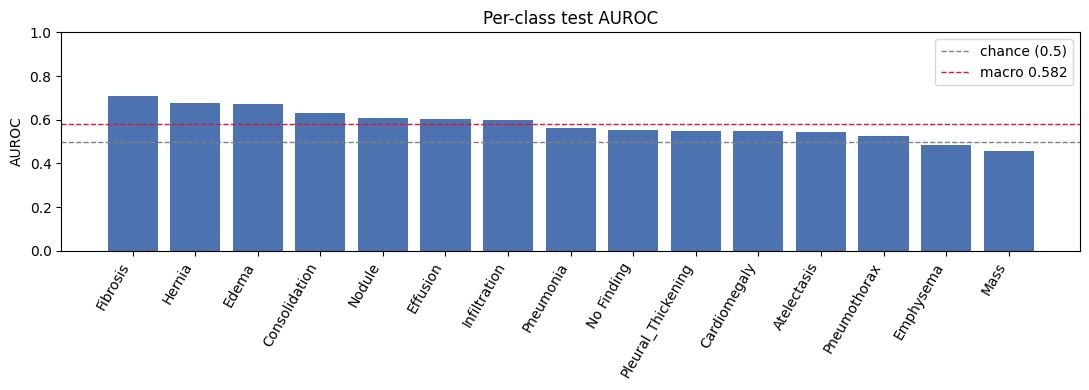

In [17]:
# 16. Per-class AUROC bar chart.
order = np.argsort(np.nan_to_num(test_aucs, nan=-1))[::-1]
plt.figure(figsize=(11, 4))
plt.bar([CLASS_NAMES[i] for i in order], [test_aucs[i] for i in order], color="#4C72B0")
plt.axhline(0.5, color="gray", ls="--", lw=1, label="chance (0.5)")
plt.axhline(test_auroc, color="crimson", ls="--", lw=1, label=f"macro {test_auroc:.3f}")
plt.ylabel("AUROC"); plt.ylim(0, 1); plt.xticks(rotation=60, ha="right")
plt.title("Per-class test AUROC"); plt.legend(); plt.tight_layout(); plt.show()

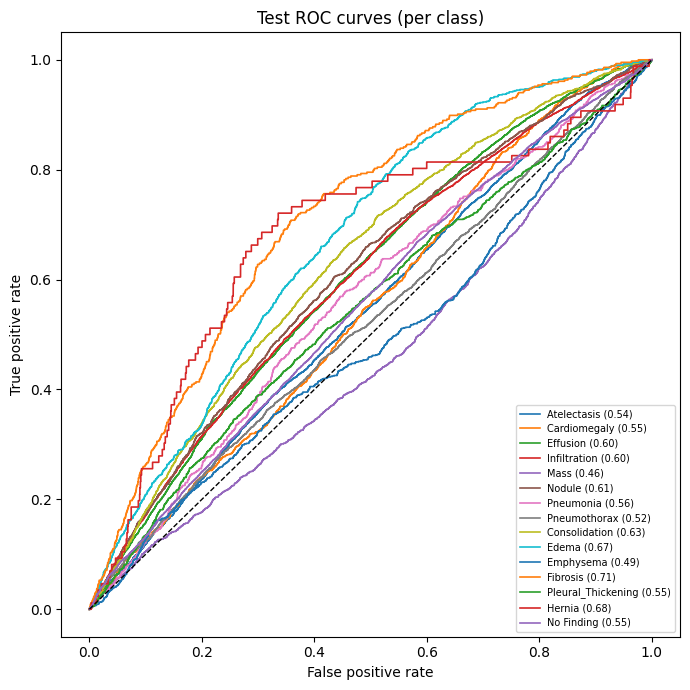

In [18]:
# 17. ROC curves for the classes that are well-populated in the test set.
plt.figure(figsize=(7, 7))
for k in range(NUM_CLASSES):
    yt = y_true[:, k]
    if yt.min() == yt.max():
        continue
    fpr, tpr, _ = roc_curve(yt, y_prob[:, k])
    plt.plot(fpr, tpr, lw=1.2, label=f"{CLASS_NAMES[k]} ({test_aucs[k]:.2f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
plt.title("Test ROC curves (per class)")
plt.legend(fontsize=7, loc="lower right"); plt.tight_layout(); plt.show()

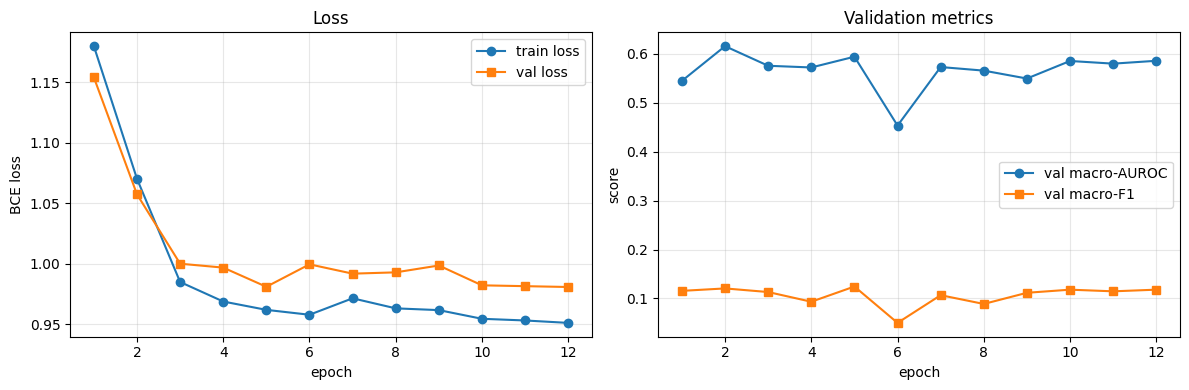

In [19]:
# 18. Training curves.
ep = range(1, len(history["train_loss"]) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(ep, history["train_loss"], "o-", label="train loss")
ax1.plot(ep, history["val_loss"],   "s-", label="val loss")
ax1.set_xlabel("epoch"); ax1.set_ylabel("BCE loss"); ax1.set_title("Loss")
ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(ep, history["val_auroc"], "o-", label="val macro-AUROC")
ax2.plot(ep, history["val_f1"],    "s-", label="val macro-F1")
ax2.set_xlabel("epoch"); ax2.set_ylabel("score"); ax2.set_title("Validation metrics")
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Save outputs

Persist everything from this run into `/kaggle/working/results_<tag>/` and zip it so
the results survive the session and download in one click from the Kaggle **Output**
tab. Saved artifacts:

- `summary.json` — macro test metrics (AUROC, F1@0.5, loss), best val AUROC, param
  count, split sizes, and the key config knobs (incl. `is_quantum: True`).
- `test_per_class_metrics.csv` — per-class AUROC and test positive counts.
- `training_history.csv` — per-epoch train/val loss and val AUROC/F1.
- `test_predictions.npz` — raw `y_true` / `y_prob` for later threshold tuning.
- `per_class_auroc.png`, `roc_curves.png`, `training_curves.png` — the three figures.
- a copy of the best checkpoint (`*_best.pt`), plus a `results_<tag>.zip` of the folder.

The `<tag>` matches `CACHE_TAG`, and the schema matches the ViT baseline's
`summary.json`, so the quantum and classical runs can be compared side by side.

In [20]:
# 19. Save all outputs (metrics, predictions, history, plots, best model) for download.
#     Written under /kaggle/working/results_vit_<tag>/ and zipped; SAME schema as the
#     HQNN run so the classical vs. quantum runs line up cleanly (is_quantum=False).
import json, shutil

RESULTS_DIR = os.path.join(WORK_DIR, f"results_vit_{CACHE_TAG}")
os.makedirs(RESULTS_DIR, exist_ok=True)

# --- 1. Per-class test metrics -> CSV ---
metrics_df = pd.DataFrame({
    "class": CLASS_NAMES,
    "auroc": [float(a) for a in test_aucs],
    "n_pos_test": [int(y_true[:, k].sum()) for k in range(NUM_CLASSES)],
}).sort_values("auroc", ascending=False, na_position="last")
metrics_df.to_csv(os.path.join(RESULTS_DIR, "test_per_class_metrics.csv"), index=False)

# --- 2. Summary: macro metrics + config + param count -> JSON ---
summary = {
    "model": "ViT baseline (classical Linear head)",
    "is_quantum": False,
    "smoke_test": SMOKE_TEST,
    "subset_images": (None if SUBSET is None else int(SUBSET)),
    "trainable_parameters": int(model_params),
    "test_loss": float(test_loss),
    "test_macro_auroc": float(test_auroc),
    "test_macro_f1@0.5": float(test_f1),
    "best_val_macro_auroc": float(best_auroc),
    "n_train": int(len(train_idx)), "n_val": int(len(val_idx)), "n_test": int(len(test_idx)),
    "epochs": EPOCHS, "batch_size": BATCH_SIZE, "img_size": IMG_SIZE,
    "bottleneck_dim": int(N_QUBITS * N_CIRCUITS), "lr": LR, "weight_decay": WEIGHT_DECAY,
    "n_qubits": N_QUBITS, "n_layers": N_LAYERS, "n_circuits": N_CIRCUITS,
    "seed": SEED, "class_names": CLASS_NAMES,
}
with open(os.path.join(RESULTS_DIR, "summary.json"), "w") as fh:
    json.dump(summary, fh, indent=2)

# --- 3. Training history (per epoch) -> CSV ---
hist_df = pd.DataFrame(history)
hist_df.insert(0, "epoch", range(1, len(hist_df) + 1))
hist_df.to_csv(os.path.join(RESULTS_DIR, "training_history.csv"), index=False)

# --- 4. Raw test predictions -> .npz (for later threshold tuning / re-plots) ---
np.savez_compressed(os.path.join(RESULTS_DIR, "test_predictions.npz"),
                    y_true=y_true, y_prob=y_prob,
                    class_names=np.array(CLASS_NAMES), test_aucs=test_aucs)

# --- 5. Re-render the three figures and save them as PNG (dpi=150) ---
order = np.argsort(np.nan_to_num(test_aucs, nan=-1))[::-1]
plt.figure(figsize=(11, 4))
plt.bar([CLASS_NAMES[i] for i in order], [test_aucs[i] for i in order], color="#4C72B0")
plt.axhline(0.5, color="gray", ls="--", lw=1, label="chance (0.5)")
plt.axhline(test_auroc, color="crimson", ls="--", lw=1, label=f"macro {test_auroc:.3f}")
plt.ylabel("AUROC"); plt.ylim(0, 1); plt.xticks(rotation=60, ha="right")
plt.title("Per-class test AUROC"); plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "per_class_auroc.png"), dpi=150, bbox_inches="tight")
plt.close()

plt.figure(figsize=(7, 7))
for k in range(NUM_CLASSES):
    yt = y_true[:, k]
    if yt.min() == yt.max():
        continue
    fpr, tpr, _ = roc_curve(yt, y_prob[:, k])
    plt.plot(fpr, tpr, lw=1.2, label=f"{CLASS_NAMES[k]} ({test_aucs[k]:.2f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
plt.title("Test ROC curves (per class)")
plt.legend(fontsize=7, loc="lower right"); plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "roc_curves.png"), dpi=150, bbox_inches="tight")
plt.close()

ep = range(1, len(history["train_loss"]) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(ep, history["train_loss"], "o-", label="train loss")
ax1.plot(ep, history["val_loss"],   "s-", label="val loss")
ax1.set_xlabel("epoch"); ax1.set_ylabel("BCE loss"); ax1.set_title("Loss")
ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(ep, history["val_auroc"], "o-", label="val macro-AUROC")
ax2.plot(ep, history["val_f1"],    "s-", label="val macro-F1")
ax2.set_xlabel("epoch"); ax2.set_ylabel("score"); ax2.set_title("Validation metrics")
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "training_curves.png"), dpi=150, bbox_inches="tight")
plt.close()

# --- 6. Copy the best checkpoint alongside the results ---
if os.path.exists(BEST_PATH):
    shutil.copy(BEST_PATH, os.path.join(RESULTS_DIR, os.path.basename(BEST_PATH)))

# --- 7. Zip everything for a one-click download ---
zip_base = os.path.join(WORK_DIR, f"results_vit_{CACHE_TAG}")
shutil.make_archive(zip_base, "zip", RESULTS_DIR)

print("Saved outputs to:", RESULTS_DIR)
for fn in sorted(os.listdir(RESULTS_DIR)):
    print("   ", fn)
print("Zipped ->", zip_base + ".zip")

Saved outputs to: /kaggle/working/results_vit_nih14_224_full
    per_class_auroc.png
    roc_curves.png
    summary.json
    test_per_class_metrics.csv
    test_predictions.npz
    training_curves.png
    training_history.csv
    vit_nih14_full_best.pt
Zipped -> /kaggle/working/results_vit_nih14_224_full.zip


## Notes & next steps

- **Classical control for the HQNN run.** This ViT baseline trains on all **112,120
  images** with NIH's official `test_list.txt` / `train_val_list.txt` split
  (`USE_OFFICIAL_SPLIT=True`) — identical to `hqnn-nih-chestxray-multilabel-full.ipynb`.
  Compare the two **test macro-AUROC / per-class AUROC / macro-F1**; the quantum-vs-
  classical ablation is the **delta** between them, since only the head differs.
- **Smoke test first.** Keep `SMOKE_TEST = True` to confirm the pipeline end-to-end
  (~500 images), then set `SMOKE_TEST = False` and **Save Version → Save & Run All
  (Commit)** for the full run.
- **GPU-bound, so fast.** With no per-batch CPU circuit simulation, epochs are much
  faster than the HQNN run and the full schedule usually finishes in one session.
  `num_workers` is held at 0 for parity with the quantum notebook (you *could* raise
  it here safely).
- **Resume is automatic.** If a session is cut off, just re-run — training resumes
  from `*_ckpt.pt`, and the **~5.3 GB** memmap cache is rebuilt once on a fresh commit
  (then reused instantly) before training. The image cache tag matches the HQNN run
  (same images/split); checkpoints use a distinct `vit_` prefix.
- **Threshold tuning:** macro-F1 here uses a fixed 0.5 threshold. For a real report,
  tune per-class thresholds on the validation set — AUROC is threshold-free.